## 1. Environment and reproducibility

The Week 7 tutorial uses synthetically generated arithmetic data, so no external dataset is required. Project 5 should be run in the IFN680 GPU environment. The random seeds below make dataset generation repeatable; GPU training may still show small run-to-run differences depending on the environment.

In [1]:
import torch
from torch import nn
from torch.nn import functional as F

import random
import math
import re
import time
import datetime
import pickle
from pathlib import Path
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

SEED = 680
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

MODEL_PATH = Path("LLMForward.pth")
TEST_DATA_PATH = Path("project5_test.pkl")

Using device: cuda


## 2. Character-level tokenizer

The tutorial vocabulary contained the digits `0–9`, `+`, `=`, `[PAD]`, and `[EOS]`. Project 5 additionally requires the `-` token for both the subtraction operator and negative answers.

This remains a **character-level** task: every digit or arithmetic symbol is represented by one token. Special tokens are used for batching and sequence termination.

In [2]:
pad_token = "[PAD]"
eos_token = "[EOS]"

class CharacterLevelTokenizer:
    """Character-level tokenizer for the Project 5 arithmetic vocabulary."""

    def __init__(self):
        self.vocab = [str(x) for x in range(10)] + ["+", "-", "="] + [pad_token, eos_token]
        self.token_to_id = {token: idx for idx, token in enumerate(self.vocab)}
        self.id_to_token = {idx: token for idx, token in enumerate(self.vocab)}
        self.ntokens = len(self.vocab)

        # Input prompts may contain spaces for readability; these are removed.
        allowed_chars = "0123456789+-="
        self.pattern = f"[^{re.escape(allowed_chars)}]"

    def clean(self, text):
        return re.sub(self.pattern, "", text)

    def pre_tokenization(self, text):
        return list(text)

    def encode(self, text):
        return [self.token_to_id[c] for c in self.pre_tokenization(self.clean(text))]

    def decode(self, token_list):
        return "".join(self.id_to_token[int(i)] for i in token_list)


tokenizer = CharacterLevelTokenizer()
ntokens = tokenizer.ntokens

print(f"Vocabulary ({ntokens} tokens): {tokenizer.vocab}")
print("Token IDs:", tokenizer.token_to_id)

Vocabulary (15 tokens): ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '+', '-', '=', '[PAD]', '[EOS]']
Token IDs: {'0': 0, '1': 1, '2': 2, '3': 3, '4': 4, '5': 5, '6': 6, '7': 7, '8': 8, '9': 9, '+': 10, '-': 11, '=': 12, '[PAD]': 13, '[EOS]': 14}


### 2.1 Tokenizer sanity checks

These checks confirm that the tokenizer can represent both operations and a negative answer. No operands are negative in Project 5; the minus token can therefore be interpreted as either the subtraction operator in the prompt or the sign of a generated answer according to its position in the sequence.

In [3]:
examples = [
    "12 + 42 = 54",
    "100 - 25 = 75",
    "25 - 100 = -75",
]

for text in examples:
    encoded = tokenizer.encode(text)
    print(f"{text:<20} -> {encoded} -> {tokenizer.decode(encoded)}")

12 + 42 = 54         -> [1, 2, 10, 4, 2, 12, 5, 4] -> 12+42=54
100 - 25 = 75        -> [1, 0, 0, 11, 2, 5, 12, 7, 5] -> 100-25=75
25 - 100 = -75       -> [2, 5, 11, 1, 0, 0, 12, 11, 7, 5] -> 25-100=-75


## 3. Synthetic arithmetic dataset

As in the tutorial, operands are non-negative integers with at most three digits (`0–999`). For Project 5, each example is either addition or subtraction:

- `a+b=` → `a+b`
- `a-b=` → `a-b`

Subtraction is allowed to produce a negative answer when `b > a`. Training, validation, and test splits are generated without overlap. The test set is **exactly balanced** between addition and subtraction to satisfy the assessment requirement and is saved for later reuse.

In [4]:
def convert_datapoint(a_int, b_int, operation):
    """Convert two operands and an operation into a (prompt, answer) tuple."""
    if operation == "+":
        result = a_int + b_int
    elif operation == "-":
        result = a_int - b_int
    else:
        raise ValueError("operation must be '+' or '-'")

    return f"{a_int}{operation}{b_int}=", str(result)


def sample_datapoint(number_digits=3, operation=None):
    """Sample one addition or subtraction example with non-negative operands."""
    max_value = (10 ** number_digits) - 1
    a_int = random.randint(0, max_value)
    b_int = random.randint(0, max_value)

    if operation is None:
        operation = random.choice(["+", "-"])

    return convert_datapoint(a_int, b_int, operation)


for operation in ["+", "-"]:
    for _ in range(3):
        print(sample_datapoint(3, operation))

('627+501=', '1128')
('871+602=', '1473')
('136+830=', '966')
('818-848=', '-30')
('524-861=', '-337')
('557-360=', '197')


### 3.1 Carry and borrow descriptors

Project 5 asks us to analyse error patterns associated with **carry** and **borrow** operations. The helpers below count how many base-10 columns generate a carry or require a borrow.

For subtraction, the count is based on the original `a-b` column operation. Negative results are kept in the dataset; the output sign is analysed separately from the numeric digit positions later in the notebook.

In [5]:
def parse_prompt(prompt):
    """Return (a, operation, b) from a prompt such as '123-45=' or '12+7='."""
    expression = prompt.rstrip("=")
    if "+" in expression:
        a, b = expression.split("+")
        return int(a), "+", int(b)
    if "-" in expression:
        a, b = expression.split("-")
        return int(a), "-", int(b)
    raise ValueError(f"Unsupported prompt: {prompt}")


def count_carries(prompt):
    """Count columns that generate a carry for an addition prompt."""
    a, operation, b = parse_prompt(prompt)
    if operation != "+":
        return 0

    carry = 0
    count = 0
    max_digits = max(len(str(a)), len(str(b)))

    for position in range(max_digits):
        digit_a = (a // (10 ** position)) % 10
        digit_b = (b // (10 ** position)) % 10
        if digit_a + digit_b + carry >= 10:
            count += 1
            carry = 1
        else:
            carry = 0
    return count


def count_borrows(prompt):
    """Count columns that require a borrow for a subtraction prompt."""
    a, operation, b = parse_prompt(prompt)
    if operation != "-":
        return 0

    borrow = 0
    count = 0
    max_digits = max(len(str(a)), len(str(b)))

    for position in range(max_digits):
        digit_a = (a // (10 ** position)) % 10
        digit_b = (b // (10 ** position)) % 10
        adjusted_a = digit_a - borrow

        if adjusted_a < digit_b:
            count += 1
            borrow = 1
        else:
            borrow = 0
    return count


sanity_examples = [
    convert_datapoint(12, 19, "+"),
    convert_datapoint(123, 456, "+"),
    convert_datapoint(500, 123, "-"),
    convert_datapoint(123, 456, "-"),
]

for sample in sanity_examples:
    prompt, answer = sample
    print(
        f"{prompt}{answer:<6} | carries={count_carries(prompt)} | borrows={count_borrows(prompt)}"
    )

12+19=31     | carries=1 | borrows=0
123+456=579    | carries=0 | borrows=0
500-123=377    | carries=0 | borrows=2
123-456=-333   | carries=0 | borrows=3


### 3.2 Balanced train / validation / test splits

The tutorial used 50,000 training, 10,000 validation, and 10,000 test examples. We retain those sizes initially, but divide each split equally between addition and subtraction. This keeps the experiment controlled while preserving the workshop scale.

If validation accuracy is still improving at the final epoch, the assessment notes that additional training epochs may be required.

In [6]:
number_digits = 3
train_size = 50_000
val_size = 10_000
test_size = 10_000

assert train_size % 2 == 0 and val_size % 2 == 0 and test_size % 2 == 0


def generate_unique_operation_samples(operation, n_samples, seen_prompts):
    samples = []
    while len(samples) < n_samples:
        prompt, answer = sample_datapoint(number_digits, operation)
        if prompt not in seen_prompts:
            seen_prompts.add(prompt)
            samples.append((prompt, answer))
    return samples


seen_prompts = set()
per_operation_total = (train_size + val_size + test_size) // 2

addition_data = generate_unique_operation_samples("+", per_operation_total, seen_prompts)
subtraction_data = generate_unique_operation_samples("-", per_operation_total, seen_prompts)

# Slice each operation separately so every split remains exactly balanced.
train_half = train_size // 2
val_half = val_size // 2
test_half = test_size // 2

data_train = (
    addition_data[:train_half]
    + subtraction_data[:train_half]
)

data_val = (
    addition_data[train_half:train_half + val_half]
    + subtraction_data[train_half:train_half + val_half]
)

data_test = (
    addition_data[train_half + val_half:train_half + val_half + test_half]
    + subtraction_data[train_half + val_half:train_half + val_half + test_half]
)

# Shuffle within each split so operations are interleaved during training/evaluation.
random.shuffle(data_train)
random.shuffle(data_val)
random.shuffle(data_test)

print(f"Train: {len(data_train):,}")
print(f"Validation: {len(data_val):,}")
print(f"Test: {len(data_test):,}")

train_prompts = {p for p, _ in data_train}
val_prompts = {p for p, _ in data_val}
test_prompts = {p for p, _ in data_test}

print("Train/val overlap:", len(train_prompts & val_prompts))
print("Train/test overlap:", len(train_prompts & test_prompts))
print("Val/test overlap:", len(val_prompts & test_prompts))

for split_name, split_data in [("train", data_train), ("val", data_val), ("test", data_test)]:
    n_add = sum("+" in prompt for prompt, _ in split_data)
    n_sub = sum("-" in prompt for prompt, _ in split_data)
    print(f"{split_name:<5}: addition={n_add:,}, subtraction={n_sub:,}")

with TEST_DATA_PATH.open("wb") as f:
    pickle.dump(data_test, f)
print(f"Saved common held-out test set to: {TEST_DATA_PATH}")

Train: 50,000
Validation: 10,000
Test: 10,000
Train/val overlap: 0
Train/test overlap: 0
Val/test overlap: 0
train: addition=25,000, subtraction=25,000
val  : addition=5,000, subtraction=5,000
test : addition=5,000, subtraction=5,000
Saved common held-out test set to: project5_test.pkl


### 3.3 Test-set arithmetic profile

Before training, we record how much of the common test set contains carries, borrows, and negative subtraction results. These categories will later support the required error analysis.

In [7]:
addition_test = [sample for sample in data_test if "+" in sample[0]]
subtraction_test = [sample for sample in data_test if "-" in sample[0]]

addition_with_carry = [sample for sample in addition_test if count_carries(sample[0]) > 0]
addition_without_carry = [sample for sample in addition_test if count_carries(sample[0]) == 0]
subtraction_with_borrow = [sample for sample in subtraction_test if count_borrows(sample[0]) > 0]
subtraction_without_borrow = [sample for sample in subtraction_test if count_borrows(sample[0]) == 0]
negative_subtraction = [sample for sample in subtraction_test if int(sample[1]) < 0]

print(f"Addition with carry:       {len(addition_with_carry):,}")
print(f"Addition without carry:    {len(addition_without_carry):,}")
print(f"Subtraction with borrow:   {len(subtraction_with_borrow):,}")
print(f"Subtraction without borrow:{len(subtraction_without_borrow):,}")
print(f"Negative subtraction:      {len(negative_subtraction):,}")

Addition with carry:       4,165
Addition without carry:    835
Subtraction with borrow:   4,200
Subtraction without borrow:800
Negative subtraction:      2,497


## 4. Positional encoding

Transformers process token embeddings in parallel and therefore need explicit information about sequence order. We retain the tutorial's sinusoidal positional encoding so that token identity and token position are represented together.

In [8]:
class PositionalEncoding(nn.Module):
    """Sinusoidal positional encoding used in the Week 7 tutorial."""

    def __init__(self, d_model, dropout=0.1, max_len=5000):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(
            (torch.arange(0, d_model, 2).float() / d_model) * (-math.log(1e4))
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0).transpose(0, 1)
        self.register_buffer("pe", pe)

    def forward(self, x):
        x = x + self.pe[:x.size(0)]
        return x

## 5. Causal Transformer model

The model architecture remains intentionally aligned with the tutorial. The main assessment change is the **task and vocabulary**, not the Transformer itself.

Pipeline:

`tokens → embedding → positional encoding → masked Transformer encoder → linear decoder → log-softmax`

The causal mask prevents a position from attending to future tokens during next-token prediction.

In [9]:
class CustomEncoderLayer(nn.TransformerEncoderLayer):
    """Transformer encoder layer that also stores per-head attention weights."""

    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.attn_weights = None

    def forward(self, src, src_mask=None, src_key_padding_mask=None, **kwargs):
        src2, attn_weights = self.self_attn(
            src,
            src,
            src,
            attn_mask=src_mask,
            key_padding_mask=src_key_padding_mask,
            need_weights=True,
            average_attn_weights=False,
        )
        self.attn_weights = attn_weights
        src = src + self.dropout1(src2)
        src = self.norm1(src)
        src2 = self.linear2(self.dropout(self.activation(self.linear1(src))))
        src = src + self.dropout2(src2)
        src = self.norm2(src)
        return src


class TransformerModel(nn.Module):
    def __init__(self, ntoken, ninp, nhead, nhid, nlayers, dropout=0.5):
        super().__init__()
        self.input_emb = nn.Embedding(ntoken, ninp)
        self.pos_encoder = PositionalEncoding(ninp, dropout)
        encoder_layers = CustomEncoderLayer(ninp, nhead, nhid, 0.1)
        self.encoder = nn.TransformerEncoder(encoder_layers, nlayers)
        self.decoder = nn.Linear(ninp, ntoken)
        self.ninp = ninp
        self.init_weights()

    def init_weights(self):
        initrange = 0.1
        nn.init.uniform_(self.input_emb.weight, -initrange, initrange)
        nn.init.zeros_(self.decoder.bias)
        nn.init.uniform_(self.decoder.weight, -initrange, initrange)

    def _generate_square_subsequent_mask(self, sz):
        return torch.log(torch.tril(torch.ones(sz, sz)))

    def forward(self, src):
        mask = self._generate_square_subsequent_mask(len(src)).to(src.device)
        src = self.input_emb(src) * math.sqrt(self.ninp)
        src = self.pos_encoder(src)
        output_enc = self.encoder(src, mask=mask)
        output_dec = self.decoder(output_enc)
        attention_maps = [layer.attn_weights for layer in self.encoder.layers]
        return F.log_softmax(output_dec, dim=-1), output_enc, attention_maps

### 5.1 Instantiate the Forward model

The hidden dimensions and number of layers are retained from the tutorial so that later Forward-vs-Reverse comparisons are not confounded by an architecture change.

In [10]:
MODEL_CONFIG = {
    "ntoken": ntokens,
    "ninp": 128,
    "nhead": 16,
    "nhid": 64,
    "nlayers": 6,
}

model = TransformerModel(**MODEL_CONFIG).to(device)

n_params = sum(p.numel() for p in model.parameters())
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(model)
print(f"Parameters: {n_params:,}")
print(f"Trainable parameters: {n_trainable:,}")

TransformerModel(
  (input_emb): Embedding(15, 128)
  (pos_encoder): PositionalEncoding(
    (dropout): Dropout(p=0.5, inplace=False)
  )
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-5): 6 x CustomEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=64, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=64, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (decoder): Linear(in_features=128, out_features=15, bias=True)
)
Parameters: 502,671
Trainable parameters: 502,671


/tmp/ipykernel_226/1612336186.py:33: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  self.encoder = nn.TransformerEncoder(encoder_layers, nlayers)


## 6. Autoregressive generation

The model predicts one token at a time. Each predicted token is appended to the current sequence and fed back into the model to predict the next token.

This retains the autoregressive generation process used in the Week 7 tutorial.

For the Forward model, answers are generated in their normal written order. For example:

`12+19=31`

is generated as:

`3 → 1 → [EOS]`

At this stage the model is still untrained, so the generated arithmetic result is not expected to be meaningful. This cell only verifies that the expanded vocabulary and generation process execute correctly.

In [11]:
def generate(model, prompts, new_tokens=5):
    """Autoregressively append predicted tokens to a batch of prompts."""
    input_tensor = prompts.to(device)

    for _ in range(new_tokens):
        output, _, _ = model(input_tensor)

        # Use the final sequence position to predict the next token.
        last_output = output[-1, :, :]
        token = torch.argmax(last_output, dim=-1).view(1, -1)

        input_tensor = torch.cat((input_tensor, token), dim=0)

    return input_tensor


# Untrained sanity check.
model.eval()

prompt = "25-100="
prompt_tensor = torch.tensor(
    tokenizer.encode(prompt),
    dtype=torch.long
).view(-1, 1)

untrained_output = generate(
    model,
    prompt_tensor,
    new_tokens=5
)[:, 0].detach().cpu().tolist()

print("Prompt:", prompt)
print("Untrained output:", tokenizer.decode(untrained_output))

Prompt: 25-100=
Untrained output: 25-100=77777


## 7. Padding and batching

Arithmetic prompts and answers have different sequence lengths, so examples must be padded before they can be processed together as a batch.

Following the tutorial:

- prompts are **left-padded**, aligning their final `=` token;
- answers are followed by `[EOS]` and then **right-padded**;
- `[EOS]` teaches the model when answer generation should terminate.

For Project 5, answer length now varies further because subtraction may include a leading negative sign.

In [12]:
def pad(token_list, type_list="prompts"):
    """Pad prompt or answer token sequences to a common batch length."""
    assert type_list in ["prompts", "answers"]

    max_length = max(len(x) for x in token_list)
    out = []

    for x in token_list:
        if type_list == "prompts":
            # Left-pad prompts so '=' aligns across the batch.
            out.append(
                [tokenizer.token_to_id[pad_token]] * (max_length - len(x))
                + x
            )

        else:
            # Append EOS, then right-pad answers.
            out.append(
                x
                + [tokenizer.token_to_id[eos_token]]
                + [tokenizer.token_to_id[pad_token]] * (max_length - len(x))
            )

    return out, max_length


batch_size = 100


def get_batch(data, start_index, batch_size=batch_size):
    """Return one padded prompt/answer batch."""
    batch = data[start_index:start_index + batch_size]

    prompts = [
        tokenizer.encode(prompt)
        for prompt, _ in batch
    ]

    answers = [
        tokenizer.encode(answer)
        for _, answer in batch
    ]

    padded_prompts, length_prompts = pad(prompts, "prompts")
    padded_answers, length_answers = pad(answers, "answers")

    X = torch.stack(
        [torch.tensor(x, dtype=torch.long) for x in padded_prompts],
        dim=1
    )

    Y = torch.stack(
        [torch.tensor(y, dtype=torch.long) for y in padded_answers],
        dim=1
    )

    return X, Y, length_prompts, length_answers


X, Y, length_prompts, length_answers = get_batch(data_train, 0)

print("Prompt batch shape:", X.shape)
print("Answer batch shape:", Y.shape)
print("Max prompt length:", length_prompts)
print("Max answer character length:", length_answers)

Prompt batch shape: torch.Size([8, 100])
Answer batch shape: torch.Size([5, 100])
Max prompt length: 8
Max answer character length: 4


## 8. Training-time evaluation

During model training, two autoregressive validation metrics are monitored.

**Token accuracy** measures the proportion of non-padding target tokens predicted correctly. This includes the `[EOS]` token.

**Sequence accuracy** measures the proportion of examples for which the entire target answer sequence is predicted correctly.

These metrics are used to monitor learning and validation convergence. They are distinct from the final Project 5 overall accuracy, which will later compare the fully decoded numeric prediction with the true numeric result.

In [13]:
from tqdm.auto import tqdm


def evaluate_autoregressive(model, input_data, desc="Validation"):
    """
    Evaluate token-level and complete-sequence autoregressive accuracy.

    A progress bar is shown because autoregressive validation generates
    answer tokens sequentially and can take noticeably longer than a
    single forward pass.
    """
    model.eval()

    correct_token = 0
    total_token = 0

    correct_sequence = 0
    total_sequence = 0

    batch_starts = range(
        0,
        len(input_data),
        batch_size
    )

    progress = tqdm(
        batch_starts,
        total=math.ceil(len(input_data) / batch_size),
        desc=desc,
        leave=False
    )

    with torch.no_grad():

        for i in progress:

            prompts, target_answers, length_prompts, length_answers = get_batch(
                input_data,
                i
            )

            prompts = prompts.to(device)
            target_answers = target_answers.to(device)

            # Generate the complete answer including EOS.
            output = generate(
                model,
                prompts,
                length_answers + 1
            )

            answer_tokens = output[
                length_prompts:,
                :
            ]

            # PAD tokens are not included in the accuracy calculation.
            target_mask = (
                target_answers
                != tokenizer.token_to_id[pad_token]
            )

            equality = (
                answer_tokens
                == target_answers
            )

            correct_token += torch.logical_and(
                target_mask,
                equality
            ).sum().item()

            total_token += target_mask.sum().item()

            correct_sequence += torch.all(
                torch.logical_or(
                    ~target_mask,
                    equality
                ),
                dim=0
            ).sum().item()

            total_sequence += target_answers.shape[1]

            progress.set_postfix(
                token_acc=f"{correct_token / max(total_token, 1):.3f}",
                seq_acc=f"{correct_sequence / max(total_sequence, 1):.3f}"
            )

    token_accuracy = correct_token / total_token
    sequence_accuracy = correct_sequence / total_sequence

    return token_accuracy, sequence_accuracy

## 9. Train the Forward model

The Forward model is trained on the balanced addition/subtraction training set using the same next-token prediction approach as the Week 7 tutorial.

The training mechanics are intentionally kept close to the supplied workshop implementation:

1. the padded prompt and complete padded target answer are concatenated;
2. the causal Transformer processes the combined sequence;
3. outputs beginning at the final prompt token (`=`) are aligned with the target answer sequence;
4. cross-entropy loss is calculated over these next-token predictions; and
5. parameters are updated using the AdamW optimiser.

The principal Task 1 changes occur in the **data and vocabulary**, rather than the Transformer training algorithm: the model now encounters both `+` and `-`, and subtraction targets may contain a leading negative sign.

A separate validation set is used to monitor convergence, as required by the assessment. Training and validation loss, token accuracy, and complete-sequence accuracy are retained for analysis. The checkpoint with the highest validation sequence accuracy is saved as `LLMForward.pth`.

The original tutorial uses 15 epochs. Project 5 notes that the addition/subtraction task may require additional training, so an initial maximum of 20 epochs is used here.

In [14]:
# Section 9 diagnostic: confirm that the GPU and one batch work correctly.

print(f"Device: {device}", flush=True)

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}", flush=True)
    print(
        f"GPU memory allocated: "
        f"{torch.cuda.memory_allocated(0) / 1024**2:.1f} MB",
        flush=True
    )

X_test, Y_test, prompt_len_test, answer_len_test = get_batch(
    data_train,
    0
)

X_test = X_test.to(device)
Y_test = Y_test.to(device)

print(f"Prompt tensor: {X_test.shape} on {X_test.device}", flush=True)
print(f"Answer tensor: {Y_test.shape} on {Y_test.device}", flush=True)

# Build the teacher-forcing sequence exactly as training will.
model_input_test = torch.cat(
    (X_test, Y_test[:-1, :]),
    dim=0
)

print(
    f"Teacher-forcing input: {model_input_test.shape}",
    flush=True
)

model.train()

output_test, _, _ = model(model_input_test)

answer_output_test = output_test[
    prompt_len_test - 1:,
    :,
    :
]

print(f"Model output: {output_test.shape}", flush=True)
print(f"Answer output: {answer_output_test.shape}", flush=True)

print("Section 9 diagnostic completed successfully.", flush=True)

Device: cuda
GPU: NVIDIA A16-4Q
GPU memory allocated: 12.8 MB
Prompt tensor: torch.Size([8, 100]) on cuda:0
Answer tensor: torch.Size([5, 100]) on cuda:0
Teacher-forcing input: torch.Size([12, 100])
Model output: torch.Size([12, 100, 15])
Answer output: torch.Size([5, 100, 15])
Section 9 diagnostic completed successfully.


In [15]:
# ============================================================
# Section 9 — Forward-model training
# ============================================================

learning_rate = 1e-3
epochs = 20
batch_size = 100


# ------------------------------------------------------------
# Start from a fresh model for the final training run.
#
# The model architecture remains unchanged from Section 5.
# ------------------------------------------------------------

model = TransformerModel(
    **MODEL_CONFIG
).to(device)


# Tutorial-aligned optimiser.
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=learning_rate
)


# ------------------------------------------------------------
# Training history
# ------------------------------------------------------------

history = {
    "train_loss": [],
    "val_loss": [],
    "train_token_accuracy": [],
    "val_token_accuracy": [],
    "train_sequence_accuracy": [],
    "val_sequence_accuracy": [],
}


best_val_sequence_accuracy = -1.0
best_epoch = 0


print(f"Training on: {device}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

print(f"Training examples: {len(data_train):,}")
print(f"Validation examples: {len(data_val):,}")
print(f"Batch size: {batch_size}")
print(f"Epochs: {epochs}")
print(f"Learning rate: {learning_rate}")
print()

# ------------------------------------------------------------
# Train one epoch
#
# The core next-token training logic below deliberately follows
# the Week 7 tutorial implementation closely.
# ------------------------------------------------------------

def train_epoch():

    model.train()

    total_loss = 0.0
    n_batches = 0

    # Shuffle training problems between epochs while preserving
    # the already-created dataset itself.
    random.shuffle(data_train)

    iterable = range(
        0,
        len(data_train),
        batch_size
    )

    progress = tqdm(
        iterable,
        total=math.ceil(len(data_train) / batch_size),
        desc="Training",
        leave=False
    )


    for i in progress:

        prompts, target_answers, length_prompts, length_answers = get_batch(
            data_train,
            i
        )

        prompts = prompts.to(device)
        target_answers = target_answers.to(device)


        # ----------------------------------------------------
        # Tutorial-style teacher forcing
        #
        # Example:
        #
        # prompt:
        #     12+19=
        #
        # target:
        #     31[EOS]
        #
        # input:
        #     12+19=31[EOS]
        #
        # Each model output is aligned with the token that
        # follows it.
        # ----------------------------------------------------

        input_tensor = torch.cat(
            (prompts, target_answers),
            0
        )


        optimizer.zero_grad()


        # Full causal Transformer forward pass.
        output, _, _ = model(
            input_tensor
        )


        # ----------------------------------------------------
        # Tutorial-aligned target extraction
        #
        # Output at '=' predicts the first answer token.
        # The final output has no following target token,
        # therefore it is excluded with :-1.
        # ----------------------------------------------------

        output_answers = output[
            length_prompts - 1:-1,
            :,
            :
        ].reshape(
            -1,
            ntokens
        )


        target_flat = target_answers.reshape(-1)


        # Tutorial-aligned loss.
        loss = F.cross_entropy(
            output_answers,
            target_flat
        )


        loss.backward()
        optimizer.step()


        total_loss += loss.item()
        n_batches += 1

        progress.set_postfix(
            loss=f"{total_loss / n_batches:.4f}"
        )


    return total_loss / n_batches

# ------------------------------------------------------------
# Teacher-forced validation loss
#
# This mirrors the tutorial validation-loss calculation.
# Autoregressive accuracy is calculated separately afterwards.
# ------------------------------------------------------------

def validation_loss():

    model.eval()

    total_loss = 0.0
    n_batches = 0

    iterable = range(
        0,
        len(data_val),
        batch_size
    )

    progress = tqdm(
        iterable,
        total=math.ceil(len(data_val) / batch_size),
        desc="Validation loss",
        leave=False
    )


    with torch.no_grad():

        for i in progress:

            prompts, target_answers, length_prompts, length_answers = get_batch(
                data_val,
                i
            )

            prompts = prompts.to(device)
            target_answers = target_answers.to(device)


            input_tensor = torch.cat(
                (prompts, target_answers),
                0
            )


            output, _, _ = model(
                input_tensor
            )


            output_answers = output[
                length_prompts - 1:-1,
                :,
                :
            ].reshape(
                -1,
                ntokens
            )


            target_flat = target_answers.reshape(-1)


            loss = F.cross_entropy(
                output_answers,
                target_flat
            )


            total_loss += loss.item()
            n_batches += 1

            progress.set_postfix(
                loss=f"{total_loss / n_batches:.4f}"
            )


    return total_loss / n_batches

# ------------------------------------------------------------
# Full training loop
# ------------------------------------------------------------

training_start_time = time.time()


for epoch in range(1, epochs + 1):

    epoch_start_time = time.time()


    # --------------------------------------------------------
    # Train
    # --------------------------------------------------------

    train_loss = train_epoch()


    # --------------------------------------------------------
    # Teacher-forced validation loss
    # --------------------------------------------------------

    val_loss = validation_loss()


    # --------------------------------------------------------
    # Autoregressive evaluation
    #
    # These use the same generation behaviour that will later
    # be used for actual arithmetic predictions.
    # --------------------------------------------------------

    train_token_accuracy, train_sequence_accuracy = evaluate_autoregressive(
        model,
        data_train,
        desc=f"Epoch {epoch:02d} train accuracy"
    )


    val_token_accuracy, val_sequence_accuracy = evaluate_autoregressive(
        model,
        data_val,
        desc=f"Epoch {epoch:02d} val accuracy"
    )


    # --------------------------------------------------------
    # Store history
    # --------------------------------------------------------

    history["train_loss"].append(
        train_loss
    )

    history["val_loss"].append(
        val_loss
    )

    history["train_token_accuracy"].append(
        train_token_accuracy
    )

    history["val_token_accuracy"].append(
        val_token_accuracy
    )

    history["train_sequence_accuracy"].append(
        train_sequence_accuracy
    )

    history["val_sequence_accuracy"].append(
        val_sequence_accuracy
    )


    # --------------------------------------------------------
    # Validation-based checkpoint selection
    # --------------------------------------------------------

    checkpoint_saved = ""


    if val_sequence_accuracy > best_val_sequence_accuracy:

        best_val_sequence_accuracy = val_sequence_accuracy
        best_epoch = epoch

        torch.save(
            model.state_dict(),
            MODEL_PATH
        )

        checkpoint_saved = " <-- saved best model"


    # --------------------------------------------------------
    # Epoch summary
    # --------------------------------------------------------

    epoch_time = time.time() - epoch_start_time


    print(
        f"Epoch {epoch:02d}/{epochs} | "
        f"Train loss: {train_loss:.4f} | "
        f"Val loss: {val_loss:.4f} | "
        f"Train token acc: {train_token_accuracy:.4f} | "
        f"Val token acc: {val_token_accuracy:.4f} | "
        f"Train seq acc: {train_sequence_accuracy:.4f} | "
        f"Val seq acc: {val_sequence_accuracy:.4f} | "
        f"Time: {epoch_time:.1f}s"
        f"{checkpoint_saved}"
    )


total_training_time = (
    time.time() - training_start_time
) / 60


print()
print("Training complete.")
print(f"Total training time: {total_training_time:.2f} min")
print(
    f"Best validation sequence accuracy: "
    f"{best_val_sequence_accuracy:.4f}"
)
print(f"Best epoch: {best_epoch}")
print(f"Saved checkpoint: {MODEL_PATH}")

/tmp/ipykernel_226/1612336186.py:33: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  self.encoder = nn.TransformerEncoder(encoder_layers, nlayers)


Training on: cuda
GPU: NVIDIA A16-4Q
Training examples: 50,000
Validation examples: 10,000
Batch size: 100
Epochs: 20
Learning rate: 0.001



Training:   0%|          | 0/500 [00:00<?, ?it/s]

Validation loss:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch 01 train accuracy:   0%|          | 0/500 [00:00<?, ?it/s]

...

Training:   0%|          | 0/500 [00:00<?, ?it/s]

Validation loss:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch 20 train accuracy:   0%|          | 0/500 [00:00<?, ?it/s]

Epoch 20 val accuracy:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch 20/20 | Train loss: 0.0993 | Val loss: 0.0165 | Train token acc: 0.9950 | Val token acc: 0.9940 | Train seq acc: 0.9810 | Val seq acc: 0.9773 | Time: 21.4s <-- saved best model

Training complete.
Total training time: 7.16 min
Best validation sequence accuracy: 0.9773
Best epoch: 20
Saved checkpoint: LLMForward.pth


### 9.1 Training and validation convergence

The training history is inspected to determine whether the model has converged before the held-out test set is used.

Following the tutorial, both training and validation loss are shown together with complete-sequence accuracy. Token accuracy is also retained because it helps distinguish partial digit learning from successful generation of the complete arithmetic result.

The test set is not used for model selection or training decisions.

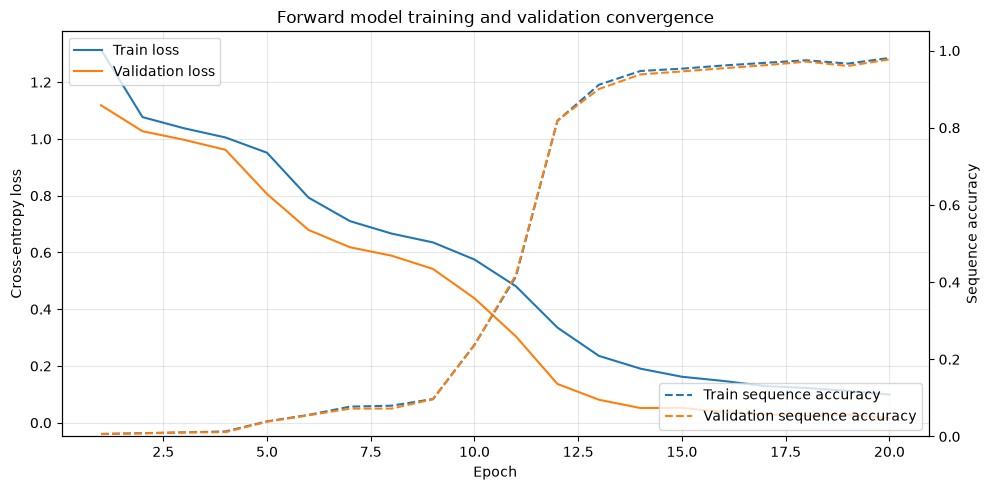

Best validation sequence accuracy: 0.9773
Best epoch: 20


In [16]:
epoch_axis = np.arange(
    1,
    len(history["train_loss"]) + 1
)


fig, ax1 = plt.subplots(
    figsize=(10, 5)
)


# ------------------------------------------------------------
# Loss
# ------------------------------------------------------------

ax1.plot(
    epoch_axis,
    history["train_loss"],
    label="Train loss"
)

ax1.plot(
    epoch_axis,
    history["val_loss"],
    label="Validation loss"
)

ax1.set_xlabel("Epoch")
ax1.set_ylabel("Cross-entropy loss")
ax1.grid(True, alpha=0.3)
ax1.legend(loc="upper left")


# ------------------------------------------------------------
# Complete-sequence accuracy
# ------------------------------------------------------------

ax2 = ax1.twinx()

ax2.plot(
    epoch_axis,
    history["train_sequence_accuracy"],
    linestyle="--",
    label="Train sequence accuracy"
)

ax2.plot(
    epoch_axis,
    history["val_sequence_accuracy"],
    linestyle="--",
    label="Validation sequence accuracy"
)

ax2.set_ylabel("Sequence accuracy")
ax2.set_ylim(0, 1.05)
ax2.legend(loc="lower right")


plt.title(
    "Forward model training and validation convergence"
)

plt.tight_layout()
plt.show()


print(
    f"Best validation sequence accuracy: "
    f"{best_val_sequence_accuracy:.4f}"
)

print(
    f"Best epoch: {best_epoch}"
)

## 10. Load the best validation checkpoint

The checkpoint with the highest validation complete-sequence accuracy is reloaded before final inference and held-out testing.

This preserves the tutorial's validation-based evaluation workflow while ensuring that the final Task 1 results are produced by the model selected using validation data rather than the held-out test set.

In [17]:
model.load_state_dict(
    torch.load(
        MODEL_PATH,
        map_location=device
    )
)

model = model.to(device)
model.eval()


print(f"Loaded checkpoint: {MODEL_PATH}")
print(
    f"Model device: "
    f"{next(model.parameters()).device}"
)
print(
    f"Selected validation sequence accuracy: "
    f"{best_val_sequence_accuracy:.4f}"
)
print(
    f"Selected epoch: {best_epoch}"
)

Loaded checkpoint: LLMForward.pth
Model device: cuda:0
Selected validation sequence accuracy: 0.9773
Selected epoch: 20


## 11. Forward-model numeric inference

Autoregressive predictions must now be converted from generated token sequences into numeric arithmetic results.

Unlike the original addition-only tutorial, Project 5 requires the negative sign to be retained. Generated tokens are therefore decoded up to `[EOS]` and interpreted as an integer only when they form a valid numeric string.

The largest possible addition result is `1998`, while the smallest subtraction result is `-999`. Five generated tokens are therefore sufficient to represent the longest answer plus `[EOS]`.

In [18]:
MAX_NEW_TOKENS = 5


def parse_prompt(prompt):
    """Return (a, operation, b) from an arithmetic prompt such as '12-19='."""
    match = re.fullmatch(
        r"(\d+)([+-])(\d+)=",
        prompt
    )

    if match is None:
        raise ValueError(
            f"Invalid arithmetic prompt: {prompt}"
        )

    a = int(match.group(1))
    operation = match.group(2)
    b = int(match.group(3))

    return a, operation, b


def decode_generated_answer(token_ids):
    """
    Decode generated answer tokens up to EOS.

    Returns:
        numeric_value: integer prediction, or None if malformed
        raw_text: generated answer text
    """
    eos_id = tokenizer.token_to_id[eos_token]
    pad_id = tokenizer.token_to_id[pad_token]

    answer_ids = []

    for token_id in token_ids:

        token_id = int(token_id)

        if token_id == eos_id:
            break

        if token_id == pad_id:
            continue

        answer_ids.append(token_id)

    raw_text = tokenizer.decode(
        answer_ids
    )

    try:
        numeric_value = int(raw_text)
    except ValueError:
        numeric_value = None

    return numeric_value, raw_text


def predict_sample(
    model,
    prompt,
    max_new_tokens=MAX_NEW_TOKENS
):
    """Generate and decode one Forward-mode arithmetic answer."""

    prompt_ids = tokenizer.encode(
        prompt
    )

    prompt_tensor = torch.tensor(
        prompt_ids,
        dtype=torch.long
    ).view(-1, 1)

    generated = generate(
        model,
        prompt_tensor,
        max_new_tokens
    )

    generated_ids = (
        generated[:, 0]
        .detach()
        .cpu()
        .tolist()
    )

    answer_token_ids = generated_ids[
        len(prompt_ids):
    ]

    return decode_generated_answer(
        answer_token_ids
    )

In [19]:
examples = [
    "12+19=",
    "999+999=",
    "500-123=",
    "500-278=",
    "123-456=",
    "0-999="
]


for prompt in examples:

    predicted, raw = predict_sample(
        model,
        prompt
    )

    a, operation, b = parse_prompt(
        prompt
    )

    actual = (
        a + b
        if operation == "+"
        else a - b
    )

    status = (
        "CORRECT"
        if predicted == actual
        else "WRONG"
    )

    print(
        f"{prompt:<10} "
        f"predicted={str(predicted):<6} "
        f"raw={raw!r:<8} "
        f"actual={actual:<6} "
        f"{status}"
    )

12+19=     predicted=11108  raw='11108'  actual=31     WRONG
999+999=   predicted=1998   raw='1998'   actual=1998   CORRECT
500-123=   predicted=377    raw='377'    actual=377    CORRECT
500-278=   predicted=222    raw='222'    actual=222    CORRECT
123-456=   predicted=-333   raw='-333'   actual=-333   CORRECT
0-999=     predicted=-9728  raw='-9728'  actual=-999   WRONG


## 12. Formal Forward-model test evaluation

The assessment defines overall accuracy using the **numeric result**, so the primary metric is exact numeric equality between prediction and ground truth.

For positional analysis, units/tens/hundreds/thousands are calculated from the **absolute numeric magnitude**, right-aligned with leading zeros where necessary. The negative sign is not a digit position and is therefore measured separately. This prevents a minus sign from shifting the units/tens alignment.

In [20]:
def predict_dataset(model, data, batch_size=batch_size):
    """Return one prediction record per example using batched autoregressive generation."""
    records = []
    model.eval()

    with torch.no_grad():
        for start in tqdm(range(0, len(data), batch_size), desc="Predict"):
            batch = data[start:start + batch_size]
            prompts_encoded = [tokenizer.encode(prompt) for prompt, _ in batch]
            padded_prompts, prompt_length = pad(prompts_encoded, "prompts")
            prompt_tensor = torch.stack(
                [torch.tensor(x, dtype=torch.long) for x in padded_prompts], dim=1
            )

            output = generate(model, prompt_tensor, MAX_NEW_TOKENS).detach().cpu()
            generated = output[prompt_length:, :]

            for column, (prompt, answer) in enumerate(batch):
                predicted, raw_prediction = decode_generated_answer(generated[:, column].tolist())
                actual = int(answer)
                _, operation, _ = parse_prompt(prompt)

                records.append({
                    "prompt": prompt,
                    "operation": operation,
                    "actual": actual,
                    "predicted": predicted,
                    "raw_prediction": raw_prediction,
                    "exact": predicted == actual,
                    "carry_count": count_carries(prompt),
                    "borrow_count": count_borrows(prompt),
                })

    return records


def accuracy(records):
    if not records:
        return float("nan")
    return sum(record["exact"] for record in records) / len(records)


def subset(records, predicate):
    return [record for record in records if predicate(record)]


test_records = predict_dataset(model, data_test)

addition_records = subset(test_records, lambda r: r["operation"] == "+")
subtraction_records = subset(test_records, lambda r: r["operation"] == "-")

print(f"Overall exact numeric accuracy: {accuracy(test_records):.2%}")
print(f"Addition accuracy:             {accuracy(addition_records):.2%}")
print(f"Subtraction accuracy:          {accuracy(subtraction_records):.2%}")

Predict:   0%|          | 0/100 [00:00<?, ?it/s]

Overall exact numeric accuracy: 97.81%
Addition accuracy:             99.00%
Subtraction accuracy:          96.62%


### 12.1 Digit-position and sign accuracy

Digit-position accuracy answers a different question from full-result accuracy: even when the complete result is wrong, **which place values are being learned reliably?**

Because the model can generate invalid strings early in training, an invalid numeric prediction is counted as incorrect for every numeric position and for the sign check.

In [24]:
# ============================================================
# Section 12.1 — Digit-position performance
# ============================================================
#
# A digit position is evaluated only when that position exists
# in the ground-truth result.
#
# For negative values, digit positions are evaluated on the
# absolute magnitude, while sign correctness is evaluated
# separately.
# ============================================================

digit_positions = {
    "Units": 0,
    "Tens": 1,
    "Hundreds": 2,
    "Thousands": 3,
}


def get_digit_if_present(value, position):
    """
    Return the digit at a place-value position only if that
    position exists in the decimal representation.

    Examples:
        7       -> units exists; tens does not
        42      -> units/tens exist
        -357    -> units/tens/hundreds exist
        1998    -> units/tens/hundreds/thousands exist
    """
    magnitude = str(abs(int(value)))

    if position >= len(magnitude):
        return None

    return int(
        magnitude[-(position + 1)]
    )


def digit_position_accuracy(records, position):
    """
    Calculate accuracy at one digit position.

    Only examples whose true result actually contains that
    position are included.
    """
    correct = 0
    total = 0

    for record in records:

        actual = record["actual"]
        predicted = record["predicted"]

        actual_digit = get_digit_if_present(
            actual,
            position
        )

        # Do not evaluate positions absent from the true result.
        if actual_digit is None:
            continue

        total += 1

        if predicted is None:
            continue

        predicted_digit = get_digit_if_present(
            predicted,
            position
        )

        if predicted_digit == actual_digit:
            correct += 1

    if total == 0:
        return None, 0

    return correct / total, total


addition_records = [
    r for r in test_records
    if r["operation"] == "+"
]

subtraction_records = [
    r for r in test_records
    if r["operation"] == "-"
]


print(
    f"{'Metric':<15}"
    f"{'All':>16}"
    f"{'Addition':>20}"
    f"{'Subtraction':>20}"
)

print("-" * 71)


for name, position in digit_positions.items():

    all_acc, all_n = digit_position_accuracy(
        test_records,
        position
    )

    add_acc, add_n = digit_position_accuracy(
        addition_records,
        position
    )

    sub_acc, sub_n = digit_position_accuracy(
        subtraction_records,
        position
    )


    def format_metric(acc, n):

        if acc is None:
            return "N/A"

        return f"{acc * 100:.2f}% (n={n})"


    print(
        f"{name:<15}"
        f"{format_metric(all_acc, all_n):>16}"
        f"{format_metric(add_acc, add_n):>20}"
        f"{format_metric(sub_acc, sub_n):>20}"
    )


# ------------------------------------------------------------
# Sign accuracy for subtraction
# ------------------------------------------------------------

sign_correct = 0
sign_total = 0

negative_exact_correct = 0
negative_total = 0


for record in subtraction_records:

    actual = record["actual"]
    predicted = record["predicted"]

    if predicted is not None:

        actual_negative = actual < 0
        predicted_negative = predicted < 0

        sign_correct += (
            actual_negative == predicted_negative
        )

        sign_total += 1


    if actual < 0:

        negative_total += 1

        if predicted == actual:
            negative_exact_correct += 1


sign_accuracy = (
    sign_correct / sign_total
)

negative_exact_accuracy = (
    negative_exact_correct / negative_total
)


print()

print(
    f"Subtraction sign accuracy: "
    f"{sign_accuracy * 100:.2f}%"
)

print(
    f"Negative-result exact accuracy: "
    f"{negative_exact_accuracy * 100:.2f}%"
)

Metric                      All            Addition         Subtraction
-----------------------------------------------------------------------
Units          98.98% (n=10000)     99.68% (n=5000)     98.28% (n=5000)
Tens            99.02% (n=9892)     99.58% (n=5000)     98.45% (n=4892)
Hundreds        99.71% (n=9004)     99.66% (n=4970)     99.78% (n=4034)
Thousands      100.00% (n=2502)    100.00% (n=2502)                 N/A

Subtraction sign accuracy: 99.96%
Negative-result exact accuracy: 97.48%


### 12.2 Carry and borrow robustness

To expose algorithmic error patterns, addition and subtraction are separated according to whether the input requires at least one carry or borrow. We also retain the carry/borrow **count**, allowing a later report notebook to investigate whether multiple carry/borrow steps are progressively harder.

In [25]:
add_no_carry = subset(addition_records, lambda r: r["carry_count"] == 0)
add_with_carry = subset(addition_records, lambda r: r["carry_count"] > 0)
sub_no_borrow = subset(subtraction_records, lambda r: r["borrow_count"] == 0)
sub_with_borrow = subset(subtraction_records, lambda r: r["borrow_count"] > 0)

print("Addition")
print(f"  No carry:    n={len(add_no_carry):4d}, accuracy={accuracy(add_no_carry):.2%}")
print(f"  With carry:  n={len(add_with_carry):4d}, accuracy={accuracy(add_with_carry):.2%}")

print()
print("Subtraction")
print(f"  No borrow:   n={len(sub_no_borrow):4d}, accuracy={accuracy(sub_no_borrow):.2%}")
print(f"  With borrow: n={len(sub_with_borrow):4d}, accuracy={accuracy(sub_with_borrow):.2%}")

print()
print("Accuracy by number of carries")
for n_carry in sorted({r["carry_count"] for r in addition_records}):
    group = subset(addition_records, lambda r, n=n_carry: r["carry_count"] == n)
    print(f"  {n_carry} carries: n={len(group):4d}, accuracy={accuracy(group):.2%}")

print()
print("Accuracy by number of borrows")
for n_borrow in sorted({r["borrow_count"] for r in subtraction_records}):
    group = subset(subtraction_records, lambda r, n=n_borrow: r["borrow_count"] == n)
    print(f"  {n_borrow} borrows: n={len(group):4d}, accuracy={accuracy(group):.2%}")

Addition
  No carry:    n= 835, accuracy=97.60%
  With carry:  n=4165, accuracy=99.28%

Subtraction
  No borrow:   n= 800, accuracy=93.12%
  With borrow: n=4200, accuracy=97.29%

Accuracy by number of carries
  0 carries: n= 835, accuracy=97.60%
  1 carries: n=1816, accuracy=98.73%
  2 carries: n=1694, accuracy=99.59%
  3 carries: n= 655, accuracy=100.00%

Accuracy by number of borrows
  0 borrows: n= 800, accuracy=93.12%
  1 borrows: n=1830, accuracy=96.07%
  2 borrows: n=1727, accuracy=98.61%
  3 borrows: n= 643, accuracy=97.20%


### 12.3 Inspect representative errors

A short qualitative inspection complements the aggregate metrics. This is useful for checking whether failures involve malformed output, the wrong sign, a specific place value, or propagation across several digits.

In [26]:
errors = [
    record
    for record in test_records
    if not record["exact"]
]


print(
    f"Total errors: "
    f"{len(errors):,} / {len(test_records):,}"
)


print()

print(
    f"{'Prompt':<12} "
    f"{'Actual':>8} "
    f"{'Predicted':>10} "
    f"{'Raw':>10} "
    f"{'Carry':>7} "
    f"{'Borrow':>7}"
)

print("-" * 72)


for record in errors[:20]:

    print(
        f"{record['prompt']:<12} "
        f"{record['actual']:>8} "
        f"{str(record['predicted']):>10} "
        f"{record['raw_prediction']:>10} "
        f"{record['carry_count']:>7} "
        f"{record['borrow_count']:>7}"
    )

Total errors: 219 / 10,000

Prompt         Actual  Predicted        Raw   Carry  Borrow
------------------------------------------------------------------------
817-819=           -2         -3         -3       0       3
879-508=          371        361        361       0       0
513-510=            3          1          1       0       0
948-944=            4          5          5       0       0
689-689=            0         -1         -1       0       0
159-161=           -2         -3         -3       0       2
542-8=            534        544        544       0       1
4-68=             -64        -65        -65       0       2
687-706=          -19        -29        -29       0       1
115-4=            111        112        112       0       0
203-996=         -793       -794       -794       0       3
231-224=            7          8          8       0       1
492-488=            4          1          1       0       1
699+600=         1299       1399       1399       1       0

## 13. Task 1 progress summary

Task 1 extended the Week 7 addition language model so that the same Forward-mode Transformer can learn both addition and subtraction.

The implementation deliberately retained the tutorial's core architecture and training process. The principal changes were:

- extending the character vocabulary with `-`;
- generating a balanced synthetic dataset containing both addition and subtraction;
- supporting negative subtraction targets when `b > a`;
- preserving the tutorial's autoregressive next-token prediction process;
- using training, validation and held-out test splits with no overlap; and
- adapting inference and evaluation so negative numeric results are decoded correctly.

The final Forward model was selected using validation complete-sequence accuracy and then evaluated once on the independent 10,000-example test set.

### Task 1 results

| Metric | Result |
| --- | ---: |
| Best validation sequence accuracy | **97.73%** |
| Held-out overall exact accuracy | **97.81%** |
| Addition exact accuracy | **99.00%** |
| Subtraction exact accuracy | **96.62%** |
| Negative-result exact accuracy | **97.48%** |
| Subtraction sign accuracy | **99.96%** |

These results indicate that the Forward model successfully learned both required operations and substantially exceeded the project's general 78% overall-accuracy expectation.

Subtraction remained somewhat more difficult than addition. Initial error inspection also showed several failures for subtraction problems where the operands were close together and the true result had a small magnitude. These observations are retained for comparison with the Reverse model in Task 3.

The Task 1 model and test set are now treated as fixed experimental artefacts. The next stage is to implement the Reverse prediction paradigm while keeping the remainder of the modelling setup as comparable as possible.

## 13. Forward-model checkpoint summary

At this point `LLMForward.ipynb` has produced the two artefacts needed later in Project 5:

- `LLMForward.pth` — the best Forward-mode model according to validation sequence accuracy;
- `project5_test.pkl` — the common held-out test set used for the Forward/Reverse comparison.

The next notebook, `LLMReverse.ipynb`, should preserve the same tokenizer, model configuration, data constraints, and evaluation definitions. Its principal experimental change will be the **target answer ordering**. This isolates prediction direction as the main independent variable in the final comparison.